In [2]:
import joblib
import os 
import sys

# sys.path
sys.path.append(os.path.abspath('../'))
rf = joblib.load(
    "../models/fraud_random_forest.pkl"
)

In [3]:
import shap

shap.initjs()

c:\Users\pc\AppData\Local\Programs\Python\Python311\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [4]:
import pandas as pd

X_test = pd.read_csv(
    "../data/processed/X_test.csv"
)

y_test = pd.read_csv(
    "../data/processed/y_test.csv"
).squeeze()

In [5]:
rf = joblib.load("../models/fraud_random_forest.pkl")

In [6]:
from src.explainability import *

importance_df = get_feature_importance(
    rf,
    X_test.columns
)

 


In [7]:
import pandas as pd

importance_df = pd.DataFrame({
    "Feature": X_test.columns,
    "Importance": rf.feature_importances_
})

importance_df = (
    importance_df
    .sort_values(
        "Importance",
        ascending=False
    )
)

importance_df.head(10)

,Feature,Importance
1,age,0.123901
0,purchase_value,0.123525
2,ip_address,0.111676
3,lower_bound_ip_address,0.101704
4,upper_bound_ip_address,0.099933
182,country_United States,0.047353
5,source_Direct,0.035240
11,sex_M,0.029959
8,browser_IE,0.019883
6,source_SEO,0.017193


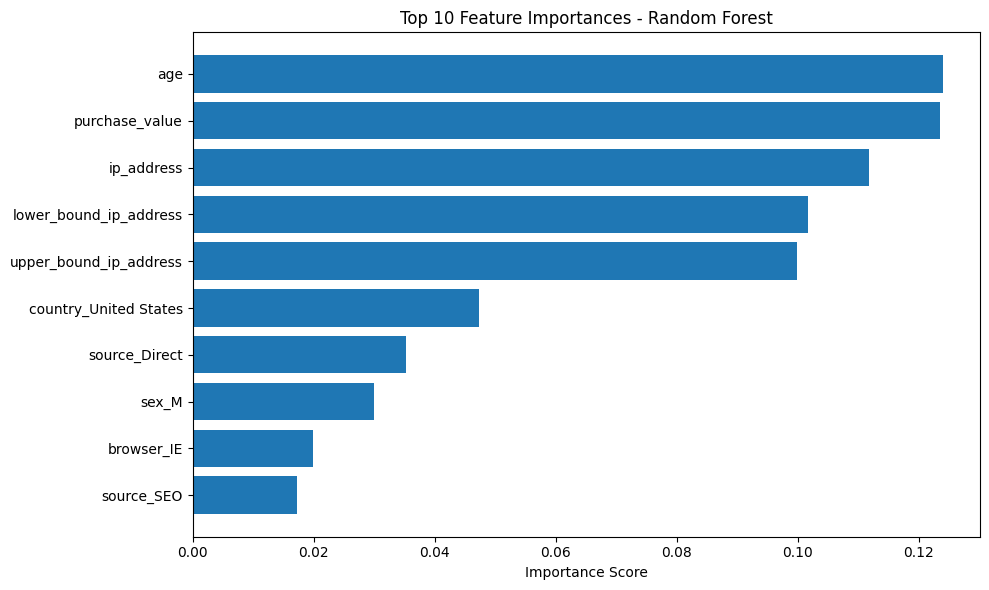

In [8]:
import matplotlib.pyplot as plt

top10 = importance_df.head(10)

plt.figure(figsize=(10, 6))

plt.barh(
    top10["Feature"],
    top10["Importance"]
)

plt.gca().invert_yaxis()

plt.title(
    "Top 10 Feature Importances - Random Forest"
)

plt.xlabel("Importance Score")
plt.tight_layout()
plt.show()

In [9]:
import shap

explainer = shap.TreeExplainer(rf)

In [10]:
X_sample = X_test.sample(
    1000,
    random_state=42
)

In [11]:
shap_values = explainer.shap_values(
    X_sample
)

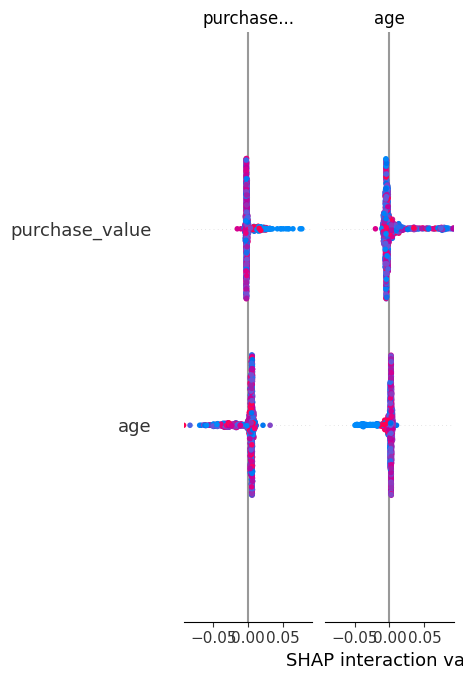

In [12]:
shap.summary_plot(
    shap_values,
    X_sample
)

In [13]:
preds = rf.predict(X_test)

tp_index = y_test[
    (preds == 1) & (y_test == 1)
].index[0]

fp_index = y_test[
    (preds == 1) & (y_test == 0)
].index[0]

fn_index = y_test[
    (preds == 0) & (y_test == 1)
].index[0]

print("TP:", tp_index)
print("FP:", fp_index)
print("FN:", fn_index)

TP: 26
FP: 1
FN: 3


In [14]:
tp_row = X_test.loc[[tp_index]]
fp_row = X_test.loc[[fp_index]]
fn_row = X_test.loc[[fn_index]]

In [15]:
tp_shap = explainer.shap_values(tp_row)
fp_shap = explainer.shap_values(fp_row)
fn_shap = explainer.shap_values(fn_row)

In [16]:
print(tp_shap.shape)
print(fp_shap.shape)
print(fn_shap.shape)

(1, 192, 2)
(1, 192, 2)
(1, 192, 2)


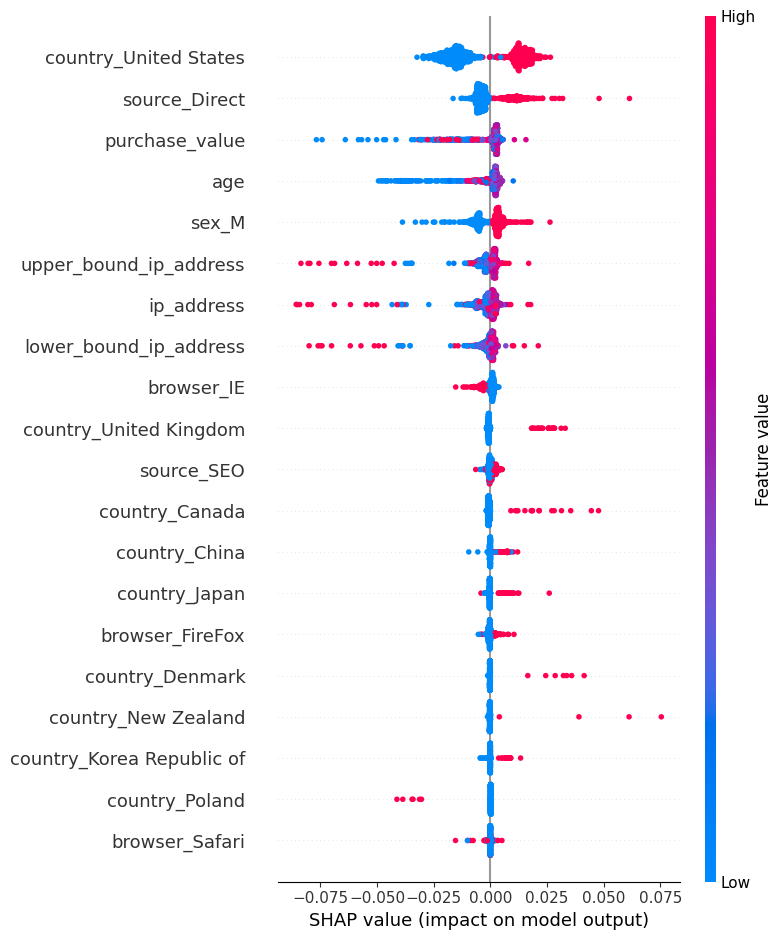

In [17]:
shap.summary_plot(
    shap_values[:, :, 1],
    X_sample
)

In [18]:
preds = rf.predict(X_test)

In [19]:
print(type(shap_values))

try:
    print(shap_values.shape)
except:
    pass

if isinstance(shap_values, list):
    for i in range(len(shap_values)):
        print(i, shap_values[i].shape)

print("tp_index =", tp_index)
print("X_test shape =", X_test.shape)

<class 'numpy.ndarray'>
(1000, 192, 2)
tp_index = 26
X_test shape = (25830, 192)


In [20]:
tp_row = X_test.loc[[tp_index]]

tp_shap = explainer.shap_values(tp_row)

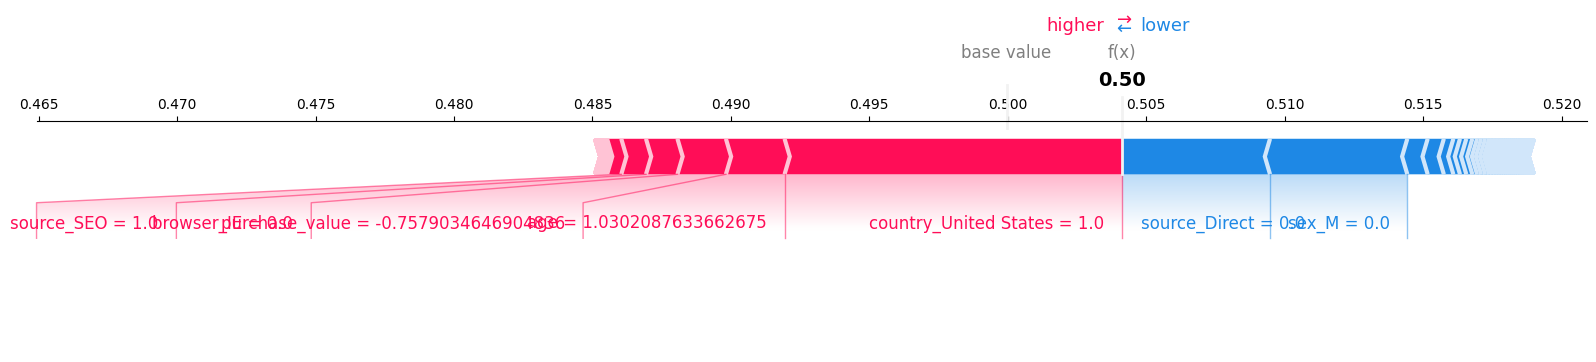

In [21]:
# True Positive
shap.force_plot(
    explainer.expected_value[1],
    tp_shap[:, :, 1][0],
    tp_row.iloc[0],
    matplotlib=True
)

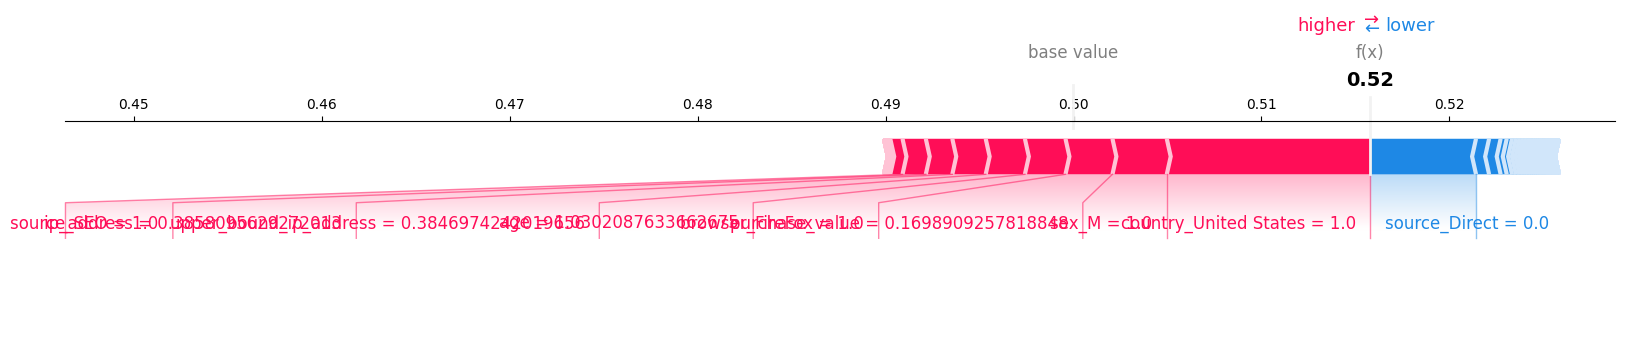

In [22]:
# False Positive
shap.force_plot(
    explainer.expected_value[1],
    fp_shap[:, :, 1][0],
    fp_row.iloc[0],
    matplotlib=True
)

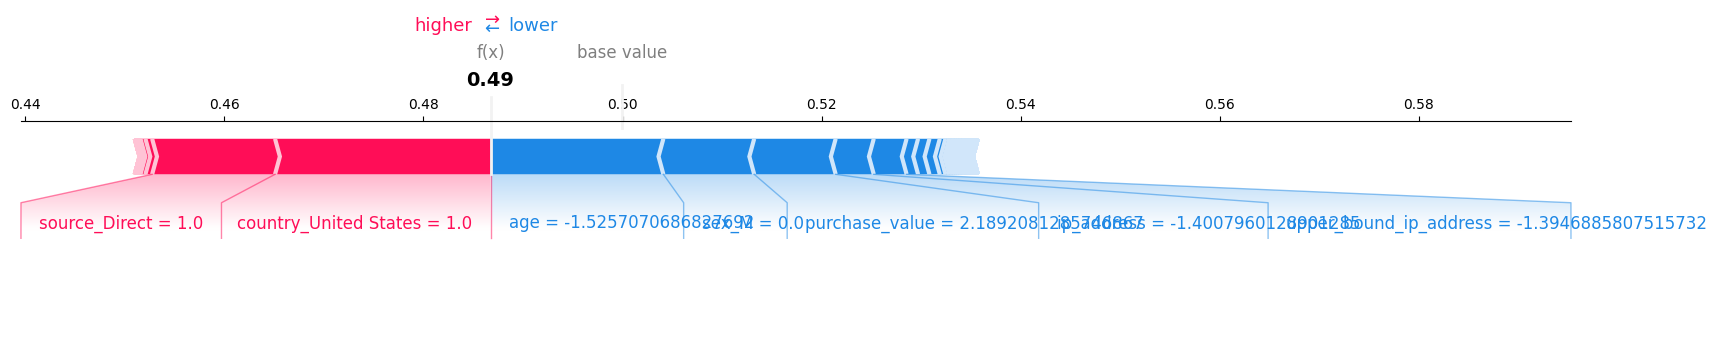

In [23]:
# False Negative
shap.force_plot(
    explainer.expected_value[1],
    fn_shap[:, :, 1][0],
    fn_row.iloc[0],
    matplotlib=True
)

In [24]:
print(X_test.columns[:20])

Index(['purchase_value', 'age', 'ip_address', 'lower_bound_ip_address',
       'upper_bound_ip_address', 'source_Direct', 'source_SEO',
       'browser_FireFox', 'browser_IE', 'browser_Opera', 'browser_Safari',
       'sex_M', 'country_Albania', 'country_Algeria', 'country_Angola',
       'country_Antigua and Barbuda', 'country_Argentina', 'country_Armenia',
       'country_Australia', 'country_Austria'],
      dtype='str')


In [25]:
print(rf.n_features_in_)
print(X_test.shape[1])

192
192
